# Clasificacion del nivel de riesgo de emergencias de transito en el canton Guayaquil

**CCPG1044 - Inteligencia Artificial | Grupo #10 | Paralelo P2**

Bohorquez Villao Andres Martin - Perez Zamora Juan Sebastian - Ullaguari Cagua John Jairo

Profesor: Enrique Pelaez J. Ph.D.

---

## Re-especificacion de la representacion

En los avances anteriores se asumio, a partir de la descripcion inicial de la
fuente, que los recursos mensuales del ECU 911 incluian coordenadas y hora del
incidente. Durante la implementacion se verifico directamente la estructura de
los archivos de distintos anios y la documentacion del dataset, y se determino
que la publicacion abierta contiene ubicacion administrativa hasta parroquia y
fecha a nivel de dia, pero **no coordenadas ni hora**. En consecuencia la
representacion computacional se ajusto a la maxima granularidad verificable:

| | Tareas #3 y #4 | Version final |
|---|---|---|
| Unidad espacial | celda de 1 km x 1 km (UTM 17S) | **parroquia** |
| Unidad temporal | franja de 3 h, \|T\| = 56 | **dia de la semana, \|T\| = 7** |
| Horizonte | una semana | una semana (sin cambio) |

El resto del diseno se conserva: instancia (unidad, dia, semana), etiqueta por
percentiles ajustados solo con entrenamiento, particion temporal, bosque
aleatorio propio y los tres componentes.

| Componente | Caso de uso | Que hace |
|---|---|---|
| 1. Procesamiento | UC1 | CSV crudos -> tensor de conteos `c[g,t,s]` |
| 2. Analisis | UC2 | `X`, `y` -> bosque aleatorio propio -> matriz de riesgo |
| 3. Visualizacion | UC3 | `streamlit run app.py` |

In [1]:
import os, sys, json, time, platform, warnings

try:
    import resource
except ImportError:
    resource = None

import psutil

def memoria_pico_mb():
    """Memoria pico del proceso en MB, compatible con Windows/Linux/macOS."""
    if platform.system() == "Windows":
        info = psutil.Process(os.getpid()).memory_info()
        pico = getattr(info, "peak_wset", info.rss)
        return pico / (1024 ** 2)

    if resource is not None:
        pico = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss

        if platform.system() == "Darwin":
            return pico / (1024 ** 2)
        return pico / 1024

    return float("nan")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from src.preprocesamiento import Preprocesador, DIAS
from src.caracteristicas import (ParticionadorTemporal, ConstructorEtiquetas,
                                 GeneradorCaracteristicas, mascara_elegibilidad,
                                 indices_de_semanas, filtrar_elegibles, BURN_IN)
from src.bosque import BosqueAleatorioPropio
from src.metricas import EvaluadorMetricas, Baselines, NOMBRES_CLASE
from src.riesgo import (MatrizRiesgo, resumen_unidades,
                        predecir_matriz_semana)

os.makedirs("salidas", exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

ENTORNO = {
    "fecha_ejecucion": pd.Timestamp.now(tz="America/Guayaquil")
                       .isoformat(timespec="seconds"),
    "python": platform.python_version(),
    "sistema": f"{platform.system()} {platform.release()}",
    "procesador": platform.processor() or platform.machine(),
    "cpus": os.cpu_count(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
print(json.dumps(ENTORNO, indent=2))
print("\nTodo tiempo reportado corresponde a ESTE entorno. Al escribir el reporte, "
      "citar la maquina donde se ejecuto, no un numero generico.")

{
  "fecha_ejecucion": "2026-08-16T03:34:31-05:00",
  "python": "3.13.14",
  "sistema": "Windows 10",
  "procesador": "Intel64 Family 6 Model 142 Stepping 9, GenuineIntel",
  "cpus": 4,
  "numpy": "2.5.2",
  "pandas": "3.0.5"
}

Todo tiempo reportado corresponde a ESTE entorno. Al escribir el reporte, citar la maquina donde se ejecuto, no un numero generico.


## 1. Componente 1 - Procesamiento de los datos (UC1)

Los CSV se descargan **manualmente** del Portal de Datos Abiertos
(https://datosabiertos.gob.ec/dataset/base-de-emergencias) y se colocan en
`datos/`. La descarga es un paso externo al sistema.

Antes de correr esta celda: `python 00_inspeccionar_csv.py datos/`, y ampliar
`_ALIAS` en `src/preprocesamiento.py` con los nombres reales de las columnas.

In [2]:
CARPETA_DATOS = "datos"

# Alcance y unidades. El dataset abierto del ECU 911 no publica coordenadas ni
# hora, asi que la unidad espacial es la parroquia y la temporal el dia de la
# semana. Ver la nota de re-especificacion al inicio del notebook.
ALCANCE            = ("canton", "GUAYAQUIL")   # o ("provincia", "GUAYAS")
NIVEL_ESPACIAL     = "parroquia"               # o "canton"
NIVEL_ELEGIBILIDAD = "unidad"                  # regla literal de la Tarea #4

pre = Preprocesador(categoria="TRANSITO", alcance=ALCANCE,
                    nivel_espacial=NIVEL_ESPACIAL)
t0 = time.perf_counter()
c, meta = pre.ejecutar(CARPETA_DATOS)
t_preproc = time.perf_counter() - t0
print(f"\nprocesamiento completo en {t_preproc:.1f} s")
print("reporte de depuracion:", pre.reporte)

# Meses no contiguos dejan semanas vacias que envenenan rezagos y percentiles.
sc = meta["semanas_con_datos"]
if len(sc) < meta["S"]:
    raise SystemExit(
        f"\nDETENIDO: solo {len(sc)} de {meta['S']} semanas tienen datos.\n"
        "Descarga los meses CONTIGUOS de julio 2021 a diciembre 2025 antes de "
        "entrenar. Con huecos, los rezagos, las medias moviles y los umbrales "
        "de la etiqueta quedan contaminados y las metricas no serian validas.")

  [01/54] emergencias_abril_2022.csv -> 4,434 registros relevantes
  [02/54] emergencias_abril_2023.csv -> 3,120 registros relevantes
  [03/54] emergencias_agosto_2021.csv -> 3,774 registros relevantes
  [04/54] emergencias_agosto_2022.csv -> 3,665 registros relevantes
  [05/54] emergencias_agosto_2023.csv -> 3,814 registros relevantes
  [06/54] emergencias_diciembre_2021.csv -> 4,481 registros relevantes
  [07/54] emergencias_diciembre_2022.csv -> 3,802 registros relevantes
  [08/54] emergencias_diciembre_2023.csv -> 4,511 registros relevantes
  [09/54] emergencias_enero_2022.csv -> 3,227 registros relevantes
  [10/54] emergencias_enero_2023.csv -> 3,571 registros relevantes
  [11/54] emergencias_febrero_2022.csv -> 3,864 registros relevantes
  [12/54] emergencias_febrero_2023.csv -> 3,374 registros relevantes
  [13/54] emergencias_julio_2021.csv -> 3,886 registros relevantes
  [14/54] emergencias_julio_2022.csv -> 4,450 registros relevantes
  [15/54] emergencias_julio_2023.csv -> 4,2

### 1.1 Analisis exploratorio

De aqui salen las decisiones que en la Tarea #4 quedaron declaradas como
hipotesis: si los umbrales de la etiqueta son viables con la granularidad real.

In [3]:
G, T, S = c.shape
print(f"G={G} unidades ({NIVEL_ESPACIAL}) | T={T} dias de semana | S={S} semanas")
print(f"eventos totales: {int(c.sum()):,}")
print(f"media por unidad-dia-semana: {c.mean():.4f}")
print(f"porcentaje de combinaciones en cero: {(c == 0).mean()*100:.2f}%")

share = c.sum(axis=(1, 2)) / c.sum()
print("\neventos por unidad:")
for i in np.argsort(share)[::-1]:
    print(f"  {meta['nombre_unidad'][i][:45]:47s} {share[i]*100:6.2f}%")

vals, cnts = np.unique(c, return_counts=True)
F = np.cumsum(cnts) / cnts.sum()
print("\ndistribucion del conteo (decide si la etiqueta de 3 clases es viable):")
for v, k, f in list(zip(vals, cnts, F))[:8]:
    print(f"  c={int(v):>3d}  n={k:>12,}  F(c<={int(v)})={f*100:6.2f}%")

G=6 unidades (parroquia) | T=7 dias de semana | S=236 semanas
eventos totales: 268,049
media por unidad-dia-semana: 27.0429
porcentaje de combinaciones en cero: 63.68%

eventos por unidad:
  GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVIN    98.86%
  JUAN GÓMEZ RENDÓN (PROGRESO)                      0.67%
  TENGUEL                                           0.22%
  POSORJA                                           0.19%
  MORRO                                             0.06%
  PUNÁ                                              0.00%

distribucion del conteo (decide si la etiqueta de 3 clases es viable):
  c=  0  n=       6,312  F(c<=0)= 63.68%
  c=  1  n=       1,288  F(c<=1)= 76.67%
  c=  2  n=         443  F(c<=2)= 81.14%
  c=  3  n=         162  F(c<=3)= 82.78%
  c=  4  n=          60  F(c<=4)= 83.38%
  c=  5  n=          20  F(c<=5)= 83.59%
  c=  6  n=           8  F(c<=6)= 83.67%
  c=  7  n=           4  F(c<=7)= 83.71%


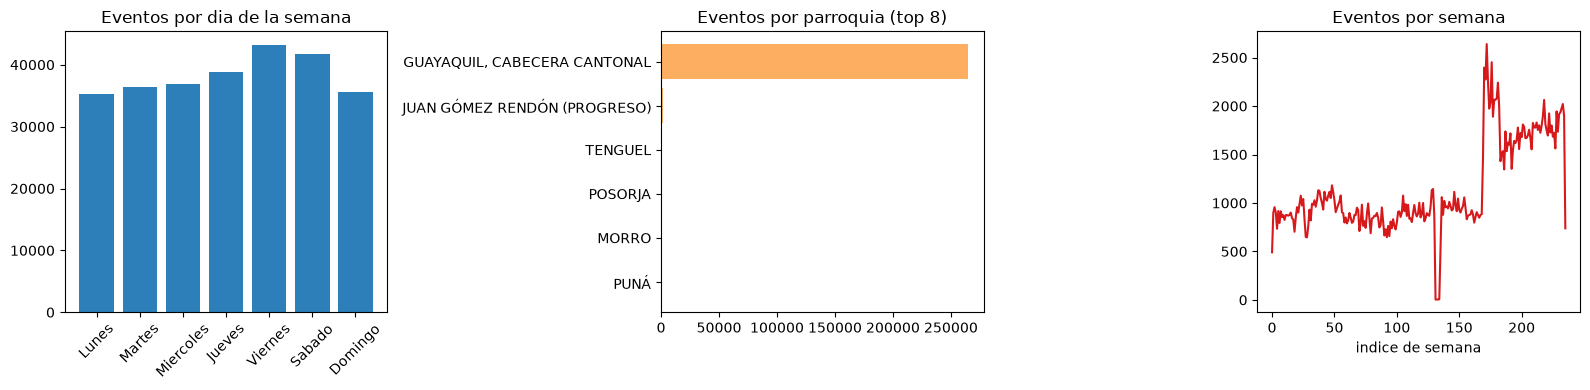

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(DIAS, c.sum(axis=(0, 2)), color="#2c7fb8")
ax[0].set_title("Eventos por dia de la semana"); ax[0].tick_params(axis="x", rotation=45)

top = np.argsort(c.sum(axis=(1, 2)))[::-1][:8]
ax[1].barh([meta["nombre_unidad"][i][:28] for i in top][::-1],
           c.sum(axis=(1, 2))[top][::-1], color="#fdae61")
ax[1].set_title(f"Eventos por {NIVEL_ESPACIAL} (top 8)")

ax[2].plot(c.sum(axis=(0, 1)), color="#d7191c")
ax[2].set_title("Eventos por semana"); ax[2].set_xlabel("indice de semana")
plt.tight_layout(); plt.savefig("salidas/exploratorio.png", dpi=130); plt.show()

## 2. Componente 2 - Analisis del riesgo (UC2)

### 2.1 Particion temporal y elegibilidad

La mascara de elegibilidad se decide **solo con la ventana de entrenamiento**.
La Tarea #4 dice que las unidades sin incidentes no ingresan al modelo, asi que se
excluyen de `X_train` y tambien de las metricas de validacion y prueba, no solo
del mapa. Una parroquia que aparece por primera vez en 2025 queda fuera: durante el
entrenamiento no existia, y sus miles de filas en cero solo inflarian la clase
baja.

In [5]:
part = ParticionadorTemporal(corte_train="2024-12-31", corte_val="2025-06-30")
sem_train, sem_val, sem_test = part.dividir(meta)

mask_elegible = mascara_elegibilidad(c, sem_train, nivel=NIVEL_ELEGIBILIDAD)
unidades_excluidas = int((~mask_elegible.any(axis=1)).sum())
print(f"  unidades excluidas por no tener historial en entrenamiento: "
      f"{unidades_excluidas} de {G}")

  particion temporal -> train=172 val=26 test=26 semanas
  elegibilidad (unidad): 42 de 42 pares unidad-dia (100.0%) ingresan al modelo
  unidades excluidas por no tener historial en entrenamiento: 0 de 6


### 2.2 Etiqueta: escalera de umbrales

El conteo es una variable discreta muy concentrada en cero. Si `np.percentile`
devuelve el mismo valor para P60 y P90, la clase media queda vacia y no existe
ningun par de umbrales sobre el conteo que produzca 60/30/10: las unicas
proporciones alcanzables son las que permite la distribucion.

`ajustarUmbrales` recorre la escalera autorizada por la Tarea #4 (global ->
positivos -> por dia) y, solo si todas colapsan, cae en cortes enteros
forzados. **Ese ultimo peldano ya no es un percentil**, y el codigo lo declara
explicitamente junto al percentil real al que equivale el corte superior. Lo que
salga de aqui es lo que hay que escribir en el reporte.

In [6]:
ce = ConstructorEtiquetas(p_bajo=60, p_alto=90, modo="auto")
P60, P90 = ce.ajustarUmbrales(c, sem_train, mask_elegible=mask_elegible)
y_tensor = ce.construirY(c)

print("\nresumen para el reporte:")
print(json.dumps(ce.resumen(), indent=2, ensure_ascii=False, default=str))

  conteos de entrenamiento (solo elegibles): 7,224 | 63.7% en cero | media=23.4164 | max=450
  escalera de umbrales:
    [global    ] OK      umbrales=0/121 -> [63.69 26.4   9.91] %

  modo adoptado: global  (base de calculo: todos)
  umbrales: bajo <= 0   alto > 121
  proporciones alcanzadas -> bajo 63.69%  medio 26.40%  alto 9.91%
  masa acumulada F(u) en los umbrales: 63.69% y 90.09%

  Los umbrales SON los percentiles 60/90, calculados con np.percentile sobre la base 'todos'. La definicion de la etiqueta de la Tarea #4 se conserva.

resumen para el reporte:
{
  "modo_usado": "global",
  "umbral_bajo": 0.0,
  "umbral_alto": 121.0,
  "corresponde_a_percentiles_solicitados": true,
  "base_de_calculo": "todos",
  "masa_acumulada_umbral_bajo_pct": 63.69047619047619,
  "masa_acumulada_umbral_alto_pct": 90.08859357696566,
  "alto_supera_medio": false,
  "proporciones_pct": [
    63.69,
    26.398,
    9.911
  ],
  "dias_colapsados": null,
  "escalera_recorrida": [
    [
      "global",
  

In [7]:
gc = GeneradorCaracteristicas()   # rezagos 1-4, medias moviles 4 y 12
t0 = time.perf_counter()
X, nombres = gc.construirX(c, meta, sem_train, semanas_futuras=1,
                           mask_elegible=mask_elegible)
t_features = time.perf_counter() - t0
St = gc.S_total
print(f"construccion de X en {t_features:.1f} s | S_total={St} (={S} observadas + 1 futura)")

# y solo existe para las semanas observadas; se rellena la futura para alinear indices
y = np.concatenate([y_tensor, np.zeros((G, T, 1), dtype=np.uint8)], axis=2).reshape(-1)

def filas(semanas):
    i = indices_de_semanas(G, T, St, semanas)
    return filtrar_elegibles(i, mask_elegible, T, St)

i_tr, i_va, i_te = filas(sem_train), filas(sem_val), filas(sem_test)
Xtr, ytr = X[i_tr], y[i_tr]
Xva, yva = X[i_va], y[i_va]
Xte, yte = X[i_te], y[i_te]

print(f"\ntrain={len(ytr):,}  val={len(yva):,}  test={len(yte):,}  (solo unidades elegibles)")
for nom, yy in (("train", ytr), ("val", yva), ("test", yte)):
    print(f"  {nom}: {np.round(np.bincount(yy, minlength=3)/len(yy)*100, 2)} %")

  bordes de discretizacion ajustados solo con filas elegibles (7,224 de 7,224)
  X: 9,954 filas x 11 variables, uint8 (0.1 MB) | 236 semanas observadas + 1 futura(s)
construccion de X en 0.0 s | S_total=237 (=236 observadas + 1 futura)

train=7,224  val=1,092  test=1,092  (solo unidades elegibles)
  train: [63.69 26.4   9.91] %
  val: [61.36 22.07 16.58] %
  test: [65.2 18.5 16.3] %


### 2.3 Entrenamiento y convergencia

Cada arbol se entrena sobre una submuestra bootstrap de a lo sumo
`maxMuestrasPorArbol` filas, no sobre el conjunto completo. Es una variante
estandar del bosque aleatorio y explica buena parte de la velocidad; hay que
reportarlo asi y no como "100 arboles sobre n millones de instancias".

In [8]:
HIPER_BASE = dict(nArboles=100, profundidadMax=12, minMuestrasHoja=5,
                  mAtributos=None, maxMuestrasPorArbol=200_000,
                  nBins=32, semilla=42, potenciaPesos=1.0)

t0 = time.perf_counter()
bosque_base = BosqueAleatorioPropio(**HIPER_BASE)
bosque_base.entrenar(Xtr, ytr)
print(f"\nn_train={len(ytr):,} | submuestra por arbol="
      f"{min(HIPER_BASE['maxMuestrasPorArbol'], len(ytr)):,} | "
      f"tiempo={bosque_base.tiempo_entrenamiento:.1f} s")
print(f"nodos por arbol (promedio): {np.mean([a.nNodos for a in bosque_base.arboles]):.0f}")

  entrenando 100 arboles | n=7,224 d=11 m=3 submuestra=7,224
  pesos de clase w_k = [0.5234 1.2627 3.3631]
    arbol   1/100  nodos=  727  prof=12     0.3s  (proy. 0.5 min)
    arbol  10/100  nodos=  719  prof=12     3.8s  (proy. 0.6 min)
    arbol  20/100  nodos=  717  prof=12     7.0s  (proy. 0.6 min)
    arbol  30/100  nodos=  641  prof=12    11.7s  (proy. 0.6 min)
    arbol  40/100  nodos=  863  prof=12    17.9s  (proy. 0.7 min)
    arbol  50/100  nodos=  837  prof=12    22.8s  (proy. 0.8 min)
    arbol  60/100  nodos=  781  prof=12    28.5s  (proy. 0.8 min)
    arbol  70/100  nodos=  785  prof=12    31.6s  (proy. 0.8 min)
    arbol  80/100  nodos=  821  prof=12    34.3s  (proy. 0.7 min)
    arbol  90/100  nodos=  709  prof=12    37.1s  (proy. 0.7 min)
    arbol 100/100  nodos=  731  prof=12    39.7s  (proy. 0.7 min)
  entrenamiento completo en 0.66 min

n_train=7,224 | submuestra por arbol=7,224 | tiempo=39.7 s
nodos por arbol (promedio): 786


  B=  1  F1 macro val = 0.8032
  B=  5  F1 macro val = 0.8208
  B= 10  F1 macro val = 0.8246
  B= 25  F1 macro val = 0.8264
  B= 50  F1 macro val = 0.8294
  B= 75  F1 macro val = 0.8303
  B=100  F1 macro val = 0.8281


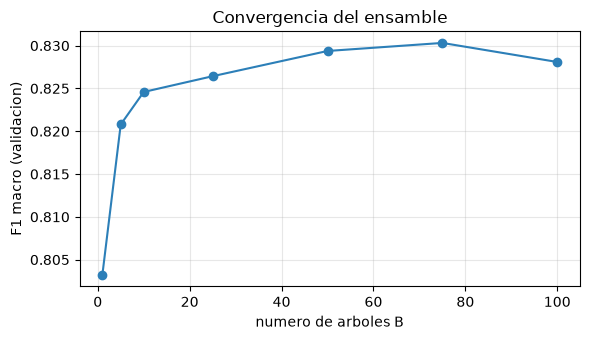

In [9]:
curva = []
for B in (1, 5, 10, 25, 50, 75, 100):
    sub = BosqueAleatorioPropio(nArboles=B, semilla=42, verboso=False)
    sub.arboles, sub.pesosClase = bosque_base.arboles[:B], bosque_base.pesosClase
    f1 = EvaluadorMetricas.f1Macro(yva, sub.predecir(Xva))
    curva.append((B, f1)); print(f"  B={B:3d}  F1 macro val = {f1:.4f}")

plt.figure(figsize=(6, 3.5))
plt.plot(*zip(*curva), "o-", color="#2c7fb8")
plt.xlabel("numero de arboles B"); plt.ylabel("F1 macro (validacion)")
plt.title("Convergencia del ensamble"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("salidas/convergencia.png", dpi=130); plt.show()

### 2.4 Ajuste de hiperparametros: buscar, elegir y **reentrenar**

La busqueda se hace solo contra validacion. El paso que faltaba: seleccionar la
combinacion ganadora y reentrenar el bosque definitivo con ella **antes** de
tocar el conjunto de prueba.

In [10]:
REJILLA = [(prof, pot) for prof in (8, 12, 16) for pot in (1.0, 0.5)]
N_ARB_BUSQUEDA = 30          # menos arboles para explorar; el definitivo usa 100

resultados = []
for prof, pot in REJILLA:
    m = BosqueAleatorioPropio(nArboles=N_ARB_BUSQUEDA, profundidadMax=prof,
                              minMuestrasHoja=HIPER_BASE["minMuestrasHoja"],
                              maxMuestrasPorArbol=HIPER_BASE["maxMuestrasPorArbol"],
                              potenciaPesos=pot, semilla=42, verboso=False)
    m.entrenar(Xtr, ytr)
    r = EvaluadorMetricas.reporte(yva, m.predecir(Xva))
    resultados.append(dict(profundidad=prof, potencia_pesos=pot,
                           f1_macro=r["f1_macro"], recall_alto=r["recall_alto"],
                           precision_alto=r["precision_alto"]))
    print(f"  prof={prof:2d} pot={pot:.1f} -> F1 macro {r['f1_macro']:.4f}  "
          f"recall alto {r['recall_alto']:.4f}  prec alto {r['precision_alto']:.4f}")

tabla_val = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
tabla_val

  prof= 8 pot=1.0 -> F1 macro 0.8233  recall alto 1.0000  prec alto 0.9945
  prof= 8 pot=0.5 -> F1 macro 0.8266  recall alto 1.0000  prec alto 0.9945
  prof=12 pot=1.0 -> F1 macro 0.8274  recall alto 1.0000  prec alto 0.9945
  prof=12 pot=0.5 -> F1 macro 0.8275  recall alto 1.0000  prec alto 0.9945
  prof=16 pot=1.0 -> F1 macro 0.8294  recall alto 1.0000  prec alto 0.9945
  prof=16 pot=0.5 -> F1 macro 0.8251  recall alto 1.0000  prec alto 0.9945


,profundidad,potencia_pesos,f1_macro,recall_alto,precision_alto
4,16,1.0,0.829375,1.0,0.994505
3,12,0.5,0.827504,1.0,0.994505
2,12,1.0,0.827352,1.0,0.994505
1,8,0.5,0.826590,1.0,0.994505
5,16,0.5,0.825109,1.0,0.994505
0,8,1.0,0.823306,1.0,0.994505


In [11]:
# Seleccion del ganador y REENTRENAMIENTO del modelo definitivo.
# Criterio: F1 macro en validacion. Si el grupo prefiere priorizar el recall de
# la clase alta (que es la metrica operativa clave), cambiar aqui la columna y
# justificarlo en el reporte.
CRITERIO = "f1_macro"

mejor = tabla_val.sort_values(CRITERIO, ascending=False).iloc[0]
HIPER = {**HIPER_BASE,
         "profundidadMax": int(mejor["profundidad"]),
         "potenciaPesos": float(mejor["potencia_pesos"])}
print(f"ganador en validacion por {CRITERIO}: profundidad={HIPER['profundidadMax']}, "
      f"potenciaPesos={HIPER['potenciaPesos']}")
print("hiperparametros definitivos:", HIPER)

if (HIPER["profundidadMax"] == HIPER_BASE["profundidadMax"]
        and HIPER["potenciaPesos"] == HIPER_BASE["potenciaPesos"]):
    print("\ncoincide con la configuracion base: se reutiliza el bosque ya entrenado")
    bosque = bosque_base
else:
    print("\nreentrenando el bosque definitivo con los hiperparametros ganadores...")
    bosque = BosqueAleatorioPropio(**HIPER)
    bosque.entrenar(Xtr, ytr)

f1_val_final = EvaluadorMetricas.f1Macro(yva, bosque.predecir(Xva))
print(f"F1 macro del modelo definitivo en validacion: {f1_val_final:.4f}")
print("A partir de aqui NO se vuelve a ajustar nada: prueba se toca una sola vez.")

ganador en validacion por f1_macro: profundidad=16, potenciaPesos=1.0
hiperparametros definitivos: {'nArboles': 100, 'profundidadMax': 16, 'minMuestrasHoja': 5, 'mAtributos': None, 'maxMuestrasPorArbol': 200000, 'nBins': 32, 'semilla': 42, 'potenciaPesos': 1.0}

reentrenando el bosque definitivo con los hiperparametros ganadores...
  entrenando 100 arboles | n=7,224 d=11 m=3 submuestra=7,224
  pesos de clase w_k = [0.5234 1.2627 3.3631]
    arbol   1/100  nodos=  981  prof=16     0.3s  (proy. 0.6 min)
    arbol  10/100  nodos= 1007  prof=16     3.8s  (proy. 0.6 min)
    arbol  20/100  nodos= 1105  prof=16     7.4s  (proy. 0.6 min)
    arbol  30/100  nodos=  999  prof=16    10.8s  (proy. 0.6 min)
    arbol  40/100  nodos= 1033  prof=16    15.4s  (proy. 0.6 min)
    arbol  50/100  nodos= 1119  prof=16    19.5s  (proy. 0.7 min)
    arbol  60/100  nodos= 1071  prof=16    24.1s  (proy. 0.7 min)
    arbol  70/100  nodos= 1093  prof=16    30.0s  (proy. 0.7 min)
    arbol  80/100  nodos= 1127 

### 2.5 Evaluacion final en prueba, baselines y benchmarks

Los baselines se calculan sobre el mismo dataset, la misma particion y las
mismas unidades elegibles. Superarlos de forma consistente es el criterio de exito
declarado.

In [12]:
proba_te = bosque.predecirProba(Xte)
pred_te = proba_te.argmax(axis=1).astype(np.uint8)

rep_propio = EvaluadorMetricas.reporte(yte, pred_te, proba_te, "bosque propio (NumPy)")
EvaluadorMetricas.imprimir(rep_propio)
reportes = [rep_propio]

# Baselines restringidos a las mismas filas elegibles
def a_filas(tensor_pred):
    return tensor_pred.reshape(-1)[
        filtrar_elegibles(indices_de_semanas(G, T, St, sem_test), mask_elegible, T, St)]

y_pad = np.concatenate([y_tensor, np.zeros((G, T, 1), dtype=np.uint8)], axis=2)
persist = np.zeros_like(y_pad)
persist[:, :, 1:] = y_pad[:, :, :-1]

moda = np.stack([(y_tensor[:, :, sem_train] == k).sum(axis=2) for k in range(3)],
                axis=-1).argmax(axis=-1).astype(np.uint8)
moda_pad = np.repeat(moda[:, :, None], St, axis=2)

for nombre, p in [
    ("baseline: clase mayoritaria", Baselines.trivial(ytr, len(yte))),
    ("baseline: persistencia",      a_filas(persist)),
    ("baseline: moda historica",    a_filas(moda_pad)),
]:
    r = EvaluadorMetricas.reporte(yte, p, None, nombre)
    EvaluadorMetricas.imprimir(r); reportes.append(r)


  --- bosque propio (NumPy) ---
  exactitud 0.8104   F1 macro 0.7783   recall clase alta 1.0000
  clase        prec   recall       F1
  bajo       0.8541   0.8553   0.8547
  medio      0.4975   0.4851   0.4912
  alto       0.9780   1.0000   0.9889
  Brier 0.2888   AUC OvR [0.8583 0.7907 1.    ]
  matriz de confusion (filas = real, columnas = predicho):
    bajo   [609  99   4]
    medio  [104  98   0]
    alto   [  0   0 178]

  --- baseline: clase mayoritaria ---
  exactitud 0.6520   F1 macro 0.2631   recall clase alta 0.0000
  clase        prec   recall       F1
  bajo       0.6520   1.0000   0.7894
  medio      0.0000   0.0000   0.0000
  alto       0.0000   0.0000   0.0000
  matriz de confusion (filas = real, columnas = predicho):
    bajo   [712   0   0]
    medio  [202   0   0]
    alto   [178   0   0]

  --- baseline: persistencia ---
  exactitud 0.7491   F1 macro 0.7141   recall clase alta 1.0000
  clase        prec   recall       F1
  bajo       0.8138   0.7978   0.8057
  medi

In [13]:
# --- BENCHMARKS EXTERNOS: solo comparacion, no forman parte de la solucion ---
try:
    from sklearn.ensemble import RandomForestClassifier
    t0 = time.perf_counter()
    rf = RandomForestClassifier(
        n_estimators=HIPER["nArboles"], max_depth=HIPER["profundidadMax"],
        min_samples_leaf=HIPER["minMuestrasHoja"], max_features="sqrt",
        class_weight="balanced", max_samples=min(HIPER["maxMuestrasPorArbol"], len(ytr)),
        bootstrap=True, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    t_sk = time.perf_counter() - t0
    r = EvaluadorMetricas.reporte(yte, rf.predict(Xte), rf.predict_proba(Xte),
                                  "sklearn RandomForest (referencia)")
    EvaluadorMetricas.imprimir(r); reportes.append(r)
    dif = abs(r["f1_macro"] - rep_propio["f1_macro"]) * 100
    print(f"\n  tiempo sklearn {t_sk:.1f}s (n_jobs=-1) vs propio "
          f"{bosque.tiempo_entrenamiento:.1f}s (1 hilo)")
    print(f"  diferencia de F1 macro: {dif:.2f} puntos "
          f"({'DENTRO' if dif <= 5 else 'FUERA'} del criterio de +/-5 puntos)")
except ImportError:
    print("scikit-learn no disponible")

try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        objective="multi:softprob", num_class=3,
                        tree_method="hist", random_state=42, n_jobs=-1)
    xgb.fit(Xtr, ytr, sample_weight=bosque.pesosClase[ytr])
    r = EvaluadorMetricas.reporte(yte, xgb.predict(Xte), xgb.predict_proba(Xte),
                                  "XGBoost (referencia)")
    EvaluadorMetricas.imprimir(r); reportes.append(r)
except ImportError:
    print("XGBoost no disponible (opcional)")


  --- sklearn RandomForest (referencia) ---
  exactitud 0.7985   F1 macro 0.7762   recall clase alta 1.0000
  clase        prec   recall       F1
  bajo       0.8607   0.8244   0.8422
  medio      0.4693   0.5297   0.4977
  alto       0.9780   1.0000   0.9889
  Brier 0.3112   AUC OvR [0.8575 0.7884 1.    ]
  matriz de confusion (filas = real, columnas = predicho):
    bajo   [587 121   4]
    medio  [ 95 107   0]
    alto   [  0   0 178]

  tiempo sklearn 0.5s (n_jobs=-1) vs propio 46.1s (1 hilo)
  diferencia de F1 macro: 0.20 puntos (DENTRO del criterio de +/-5 puntos)
XGBoost no disponible (opcional)


In [14]:
comparativa = pd.DataFrame([{
    "modelo": r["modelo"], "exactitud": round(r["exactitud"], 4),
    "F1 macro": round(r["f1_macro"], 4),
    "F1 bajo": round(r["f1_por_clase"][0], 4),
    "F1 medio": round(r["f1_por_clase"][1], 4),
    "F1 alto": round(r["f1_por_clase"][2], 4),
    "recall alto": round(r["recall_alto"], 4),
    "Brier": round(r["brier"], 4) if "brier" in r else None,
} for r in reportes]).sort_values("F1 macro", ascending=False)
comparativa

,modelo,exactitud,F1 macro,F1 bajo,F1 medio,F1 alto,recall alto,Brier
0,bosque propio (NumPy),0.8104,0.7783,0.8547,0.4912,0.9889,1.0000,0.2888
4,sklearn RandomForest (referencia),0.7985,0.7762,0.8422,0.4977,0.9889,1.0000,0.3112
2,baseline: persistencia,0.7491,0.7141,0.8057,0.3478,0.9889,1.0000,NaN
3,baseline: moda historica,0.7738,0.7096,0.8639,0.4404,0.8247,0.7135,NaN
1,baseline: clase mayoritaria,0.6520,0.2631,0.7894,0.0000,0.0000,0.0000,NaN


### 2.6 Desempeno por parroquia

La cabecera cantonal concentra alrededor del 98.7 % de los eventos, asi que un
buen F1 macro agregado podria deberse solo a ella. Esta tabla responde
directamente a esa objecion: muestra el desempeno unidad por unidad, junto con
el numero de instancias y la distribucion de clases de cada una, porque en
parroquias con pocas instancias o con alguna clase ausente el F1 macro aislado
es inestable y no debe leerse igual que el de la cabecera.

In [15]:
# El aplanado sigue el orden (g, t, s), asi que la unidad de una fila es:
g_test = i_te // (T * St)

filas = []
for g in np.unique(g_test):
    m = g_test == g
    if m.sum() == 0:
        continue
    r = EvaluadorMetricas.reporte(yte[m], pred_te[m], proba_te[m],
                                  str(meta["nombre_unidad"][g]))
    pres = np.bincount(yte[m], minlength=3)
    filas.append({
        "parroquia": str(meta["nombre_unidad"][g])[:40],
        "n": int(m.sum()),
        "clases_presentes": int((pres > 0).sum()),
        "dist_bajo_medio_alto": "/".join(f"{v}" for v in pres),
        "exactitud": round(r["exactitud"], 4),
        "f1_macro": round(r["f1_macro"], 4),
        "recall_alto": round(r["recall_alto"], 4),
        "precision_alto": round(r["precision_alto"], 4),
    })

metricas_por_unidad = pd.DataFrame(filas).sort_values("n", ascending=False)
if (metricas_por_unidad["clases_presentes"] < 3).any():
    print("[aviso] hay parroquias sin las tres clases en prueba: su F1 macro no "
          "es comparable con el de las que si las tienen. Leerlo junto con n y "
          "la distribucion de clases.")
metricas_por_unidad

[aviso] hay parroquias sin las tres clases en prueba: su F1 macro no es comparable con el de las que si las tienen. Leerlo junto con n y la distribucion de clases.


,parroquia,n,clases_presentes,dist_bajo_medio_alto,exactitud,f1_macro,recall_alto,precision_alto
0,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL P",182,2,4/0/178,0.9780,0.3296,1.0,0.978
1,JUAN GÓMEZ RENDÓN (PROGRESO),182,2,86/96/0,0.5110,0.2255,0.0,0.000
2,MORRO,182,2,169/13/0,0.9286,0.3210,0.0,0.000
3,POSORJA,182,2,133/49/0,0.7253,0.2927,0.0,0.000
4,PUNÁ,182,2,177/5/0,0.9725,0.3287,0.0,0.000
5,TENGUEL,182,2,143/39/0,0.7473,0.3333,0.0,0.000


### 2.6 Interpretabilidad y calibracion

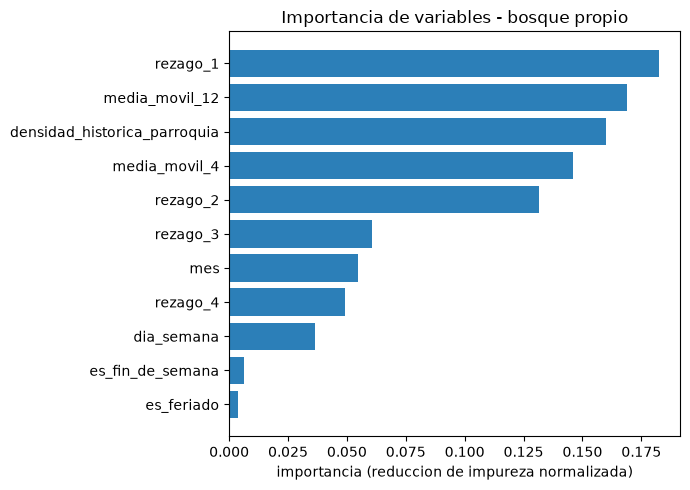

  rezago_1                     18.23 %
  media_movil_12               16.90 %
  densidad_historica_parroquia 16.01 %
  media_movil_4                14.61 %
  rezago_2                     13.15 %
  rezago_3                      6.06 %
  mes                           5.47 %
  rezago_4                      4.93 %


In [16]:
imp = bosque.importanciaVariables()
orden = np.argsort(imp)[::-1]
plt.figure(figsize=(7, 5))
plt.barh([nombres[i] for i in orden][::-1], imp[orden][::-1], color="#2c7fb8")
plt.xlabel("importancia (reduccion de impureza normalizada)")
plt.title("Importancia de variables - bosque propio")
plt.tight_layout(); plt.savefig("salidas/importancias.png", dpi=130); plt.show()
for i in orden[:8]:
    print(f"  {nombres[i]:28s} {imp[i]*100:5.2f} %")

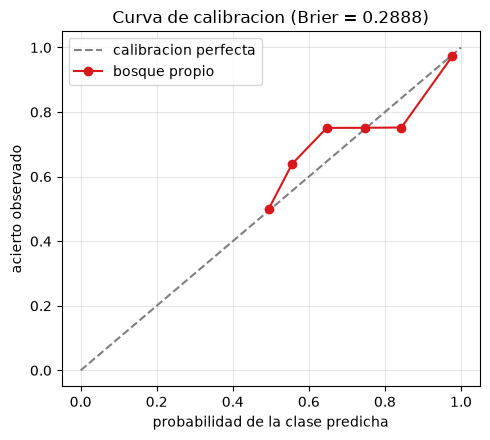

In [17]:
xs, ys, ns = EvaluadorMetricas.curvaCalibracion(yte, proba_te, nBins=10)
plt.figure(figsize=(5, 4.5))
plt.plot([0, 1], [0, 1], "--", color="grey", label="calibracion perfecta")
plt.plot(xs, ys, "o-", color="#d7191c", label="bosque propio")
plt.xlabel("probabilidad de la clase predicha"); plt.ylabel("acierto observado")
plt.title(f"Curva de calibracion (Brier = {rep_propio['brier']:.4f})")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("salidas/calibracion.png", dpi=130); plt.show()

## 3. Matriz de riesgo de la semana SIGUIENTE

Esta es la prediccion que exige el objetivo: la semana inmediatamente posterior
a la ultima semana completa disponible, cuya etiqueta todavia no existe.

Sus caracteristicas se construyen con `c[S-1] ... c[S-4]` como rezagos y las
medias moviles hasta `S-1`. Ninguna lee `c[S]`, que es justamente el valor
desconocido: `tests/test_pipeline.py` lo verifica alterando `c[S]` y comprobando
que las caracteristicas no cambian.

In [18]:
i_sig = gc.indices_semana_futura(G, T, S, k=0)
fecha_obj = gc.fecha_semana_futura(0)
print(f"ultima semana observada : {pd.Timestamp(meta['fecha_semana'][-1]).date()}")
print(f"semana objetivo (S)     : {fecha_obj.date()}   <- la que se predice")
assert len(i_sig) == G * T

# Solo las unidades elegibles pasan por el modelo. El resto de la matriz queda
# en NaN y se muestra en gris: no es que el clasificador les asigne riesgo bajo,
# es que no opina sobre ellas.
proba_sig, n_predichas = predecir_matriz_semana(bosque, X, i_sig, mask_elegible)
print(f"filas enviadas al modelo: {n_predichas} de {G*T} "
      f"({G*T - n_predichas} unidades-dia sin datos suficientes)")

mr = MatrizRiesgo(meta, fecha_obj, umbrales=(P60, P90))
mr.desde_predicciones(proba_sig, mascara_sin_datos=~mask_elegible)
print("\nresumen de la matriz:", mr.resumen())
mr.guardar("salidas/matriz_riesgo.parquet")
mr.a_dataframe().sort_values("prob_clase_predicha", ascending=False).head(10)

ultima semana observada : 2025-12-29
semana objetivo (S)     : 2026-01-05   <- la que se predice
filas enviadas al modelo: 42 de 42 (0 unidades-dia sin datos suficientes)

resumen de la matriz: {'Bajo': 28, 'Medio': 7, 'Alto': 7}
  matriz de riesgo guardada en salidas/matriz_riesgo.parquet (42 filas)


,unidad_id,unidad,canton,unidad_idx,dia_idx,dia_semana,nivel_cod,nivel,prob_clase_predicha,p_bajo,p_medio,p_alto,semana_objetivo
31,90157,PUNÁ,GUAYAQUIL,4,3,Jueves,0,Bajo,0.968738,0.968738,0.031262,0.000000,2026-01-05
30,90157,PUNÁ,GUAYAQUIL,4,2,Miercoles,0,Bajo,0.967435,0.967435,0.032565,0.000000,2026-01-05
28,90157,PUNÁ,GUAYAQUIL,4,0,Lunes,0,Bajo,0.963050,0.963050,0.036950,0.000000,2026-01-05
33,90157,PUNÁ,GUAYAQUIL,4,5,Sabado,0,Bajo,0.961277,0.961277,0.038722,0.000000,2026-01-05
2,90150,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAQUIL,0,2,Miercoles,2,Alto,0.935654,0.012961,0.051385,0.935654,2026-01-05
1,90150,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAQUIL,0,1,Martes,2,Alto,0.920297,0.011956,0.067747,0.920297,2026-01-05
0,90150,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAQUIL,0,0,Lunes,2,Alto,0.915712,0.011956,0.072332,0.915712,2026-01-05
29,90157,PUNÁ,GUAYAQUIL,4,1,Martes,0,Bajo,0.914218,0.914218,0.085782,0.000000,2026-01-05
14,90153,MORRO,GUAYAQUIL,2,0,Lunes,0,Bajo,0.862247,0.862247,0.137753,0.000000,2026-01-05
35,90158,TENGUEL,GUAYAQUIL,5,0,Lunes,0,Bajo,0.861204,0.861204,0.138796,0.000000,2026-01-05


In [19]:
with open("salidas/unidades.json", "w", encoding="utf-8") as f:
    json.dump(resumen_unidades(meta), f, ensure_ascii=False)

metricas = {
    "entorno": ENTORNO,
    "comparativa": comparativa.to_dict(orient="records"),
    "por_unidad": metricas_por_unidad.to_dict(orient="records"),
    "importancias": [{"variable": nombres[i], "importancia": float(imp[i])} for i in orden],
    "busqueda_validacion": tabla_val.to_dict(orient="records"),
    "hiperparametros": {**HIPER, "criterio_seleccion": CRITERIO,
                        "f1_macro_validacion": round(float(f1_val_final), 4)},
    "etiqueta": ce.resumen(),
    "representacion": {
        "unidad_espacial": NIVEL_ESPACIAL,
        "unidad_temporal": "dia de la semana",
        "T": int(T),
        "alcance": list(ALCANCE),
        "nota": ("El dataset abierto del ECU 911 no publica coordenadas ni hora; "
                 "las unidades se ajustaron a la maxima granularidad verificable "
                 "en la fuente."),
    },
    "alcance": {
        "nivel_elegibilidad": NIVEL_ELEGIBILIDAD,
        "G_total": int(G), "G_elegibles": int(mask_elegible.any(axis=1).sum()),
        "unidades_excluidas_sin_historial": unidades_excluidas,
        "n_train": int(len(ytr)), "n_val": int(len(yva)), "n_test": int(len(yte)),
        "d": int(X.shape[1]),
        "submuestra_por_arbol": int(min(HIPER["maxMuestrasPorArbol"], len(ytr))),
    },
    "tiempos_s": {"preprocesamiento": round(t_preproc, 1),
                  "construccion_X": round(t_features, 1),
                  "entrenamiento_bosque_definitivo": round(bosque.tiempo_entrenamiento, 1)},
    "memoria_pico_MB": round(memoria_pico_mb(), 1),
    "semana_objetivo": str(fecha_obj.date()),
}
with open("salidas/metricas.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2, default=str)

import joblib
joblib.dump({"bosque": bosque, "umbrales": (P60, P90), "nombres": nombres,
             "mask_elegible": mask_elegible, "meta": meta}, "salidas/modelo.joblib")
print("artefactos listos en salidas/. Ahora: streamlit run app.py")

artefactos listos en salidas/. Ahora: streamlit run app.py


## 4. Verificacion de la implementacion propia

Doble via, como quedo declarado en la Tarea #4, mas las pruebas de regresion de
los fallos corregidos el 15 de agosto.

In [20]:
print("Via 1 - pruebas unitarias del Gini contra casos resueltos a mano:")
os.system(f"{sys.executable} -m tests.test_gini")

print("\nPruebas de regresion del pipeline:")
os.system(f"{sys.executable} -m tests.test_pipeline")
os.system(f"{sys.executable} -m tests.test_representacion")

print("\nVia 2 - comparacion contra sklearn con hiperparametros identicos:")
print("  ver la tabla comparativa de la seccion 2.5")

Via 1 - pruebas unitarias del Gini contra casos resueltos a mano:

Pruebas de regresion del pipeline:

Via 2 - comparacion contra sklearn con hiperparametros identicos:
  ver la tabla comparativa de la seccion 2.5


---

## Que copiar al reporte final

Al terminar la ejecucion, `salidas/metricas.json` contiene todo lo que exige la
rubrica en las secciones 6 y 7:

- **Implementacion**: `entorno` (hardware y software reales), `hiperparametros`
  con el criterio de seleccion, `alcance.submuestra_por_arbol`.
- **Resultados**: `comparativa` (modelo propio vs. baselines vs. referencias),
  `importancias`, `tiempos_s`, `memoria_pico_MB`.
- **Definicion del problema**: `etiqueta`, que declara en que peldano de la
  escalera se detuvo el ajuste y, si aplica, que los umbrales adoptados no son
  los percentiles 60/90 y a que percentil equivalen realmente.

Guardar tambien la salida ejecutada de este notebook: un notebook con
`execution_count = None` no acredita ninguna medicion.